<a href="https://www.kaggle.com/code/mykolarekunenko/notebook-claude?scriptVersionId=293503066" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

ІМПОРТ БІБЛІОТЕК

In [89]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
import numpy as np

# Налаштування пристрою (GPU або CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Використовується пристрій: {device}')

Використовується пристрій: cuda


ПІДГОТОВКА ДАНИХ

In [90]:
# Завантаження датасету фруктів
data_dir = '/kaggle/input/fruit-recognition/train/train'
dataset = datasets.ImageFolder(data_dir)

In [91]:
# Розділення на навчальну та тестову вибірки (80% / 20%)
data_train, data_test = torch.utils.data.random_split(dataset, [0.8, 0.2])
print(f'Навчальна вибірка: {len(data_train)} зображень')
print(f'Тестова вибірка: {len(data_test)} зображень')
print(f'Кількість класів: {len(dataset.classes)}')

Навчальна вибірка: 13484 зображень
Тестова вибірка: 3370 зображень
Кількість класів: 33


In [92]:
# Аугментація даних для навчання (збільшення різноманітності)
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),  # Зміна розміру до 64x64
    transforms.RandomRotation(180),  # Випадковий поворот до 180°
    transforms.RandomHorizontalFlip(p=0.5),  # Горизонтальне віддзеркалення
    transforms.RandomVerticalFlip(p=0.5),  # Вертикальне віддзеркалення
    transforms.ToTensor()  # Перетворення в тензор
])

In [93]:
# Трансформація для тестових даних (без аугментації)
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

In [94]:
# Клас для застосування трансформацій до датасету
class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        img_new = self.transformer(img)
        return img_new, label

In [95]:
# Створення датасетів із трансформаціями
traindata = TransformDataset(data_train, train_transform)
testdata = TransformDataset(data_test, test_transform)

In [96]:
# Створення завантажувачів даних
trainloader = DataLoader(traindata, batch_size=256, shuffle=True)
testloader = DataLoader(testdata, batch_size=256)

ПОБУДОВА МОДЕЛІ

In [97]:
# Архітектура нейронної мережі
model = nn.Sequential(
    nn.Flatten(),  # Розгортання 3D тензора в 1D вектор
    nn.Linear(3*64*64, 128),  # Перший повнозв'язний шар
    nn.ReLU(),  # Функція активації
    nn.Linear(128, 64),  # Другий повнозв'язний шар
    nn.ReLU(),
    nn.Linear(64, 33)  # Вихідний шар (33 класи)
).to(device)

print('\nМодель створена')


Модель створена


ФУНКЦІЯ ВІЗУАЛІЗАЦІЇ ПЕРЕДБАЧЕНЬ

In [98]:
def show_predictions(model, dataloader, dataset_obj, n_images=8, title="Передбачення"):
    """Показує передбачення моделі на зображеннях"""
    model.eval()
    images, labels = next(iter(dataloader))
    images = images[:n_images].to(device)
    labels = labels[:n_images]

    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle(title, fontsize=16, fontweight='bold')

    for idx, ax in enumerate(axes.flat):
        if idx < n_images:
            img = images[idx].cpu().permute(1, 2, 0).numpy()
            pred_class = predicted[idx].cpu().item()
            true_class = labels[idx].item()
            confidence = probabilities[idx][pred_class].cpu().item() * 100

            pred_label = dataset_obj.classes[pred_class]
            true_label = dataset_obj.classes[true_class]
            color = 'green' if pred_class == true_class else 'red'

            ax.imshow(img)
            ax.axis('off')
            ax.set_title(f'Передбачення: {pred_label}\nПравильно: {true_label}\nВпевненість: {confidence:.1f}%', 
                        color=color, fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

ПЕРЕДБАЧЕННЯ ДО НАВЧАННЯ


ПЕРЕДБАЧЕННЯ ДО НАВЧАННЯ (випадкові ваги)


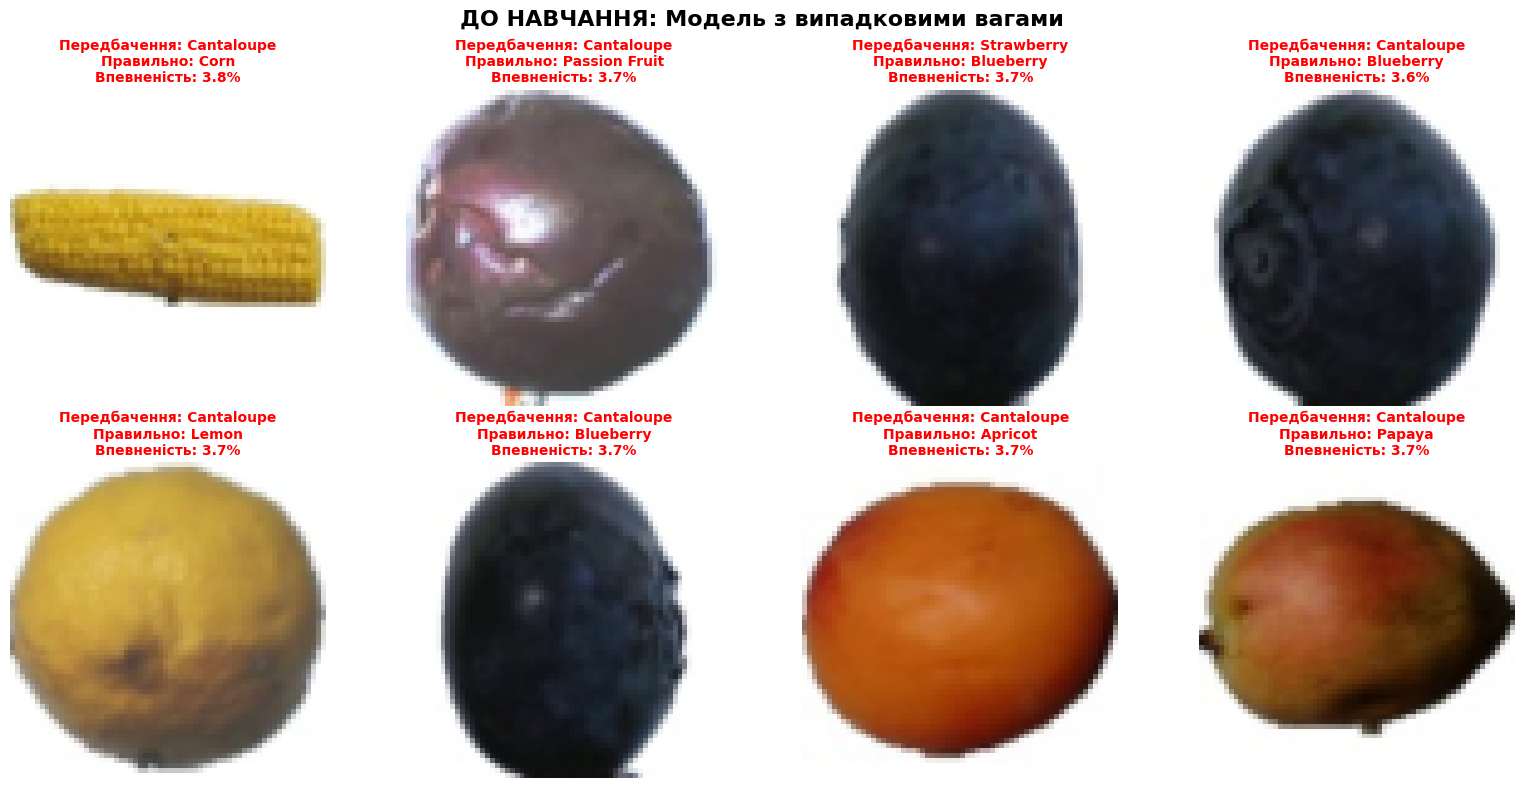

Точність ДО навчання: 3.20%


In [99]:
print('\n' + '='*60)
print('ПЕРЕДБАЧЕННЯ ДО НАВЧАННЯ (випадкові ваги)')
print('='*60)

show_predictions(model, testloader, dataset, n_images=8, 
                title="ДО НАВЧАННЯ: Модель з випадковими вагами")

# Точність ДО навчання
model.eval()
correct_before = 0
total_before = 0

with torch.no_grad():
    for imgs, labels in testloader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        predictions = model(imgs).argmax(1)
        correct_before += (predictions == labels).sum().item()
        total_before += len(labels)

accuracy_before = (correct_before / total_before) * 100
print(f'Точність ДО навчання: {accuracy_before:.2f}%')

НАВЧАННЯ МОДЕЛІ

In [100]:
print('\n' + '='*60)
print('НАВЧАННЯ МОДЕЛІ')
print('='*60)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

losslist = []
losstestlist = []
accuracytrainlist = []
accuracytestlist = []
avg_train_acc_list = []
avg_test_acc_list = []

n_epochs = 10

for epoch in range(1, n_epochs + 1):
    # ----- ТРЕНУВАННЯ -----
    model.train()
    epoch_train_acc = 0

    for imgs, labels in trainloader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        # accuracy
        correct = (outputs.argmax(1) == labels).sum().item()
        batch_acc = correct / len(labels)
        epoch_train_acc += batch_acc

        # зберігаємо для графіка
        losslist.append(loss.item())
        accuracytrainlist.append(batch_acc)

    # ----- ВАЛІДАЦІЯ (УСЕРЕДИНІ ЦИКЛУ ЕПОХИ!) -----
    model.eval()
    epoch_test_acc = 0

    with torch.no_grad():
        for imgs, labels in testloader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            loss = loss_fn(outputs, labels)

            correct = (outputs.argmax(1) == labels).sum().item()
            batch_acc_test = correct / len(labels)
            epoch_test_acc += batch_acc_test

            # зберігаємо для графіка
            losstestlist.append(loss.item())
            accuracytestlist.append(batch_acc_test)

    avg_train_acc = (epoch_train_acc / len(trainloader)) * 100
    avg_test_acc = (epoch_test_acc / len(testloader)) * 100
    avg_train_acc_list.append(avg_train_acc)
    avg_test_acc_list.append(avg_test_acc)

    print(f'Епоха {epoch}/{n_epochs}: '
          f'Train Accuracy: {avg_train_acc:.2f}% '
          f'Test Accuracy: {avg_test_acc:.2f}%')


НАВЧАННЯ МОДЕЛІ
Епоха 1/10: Train Accuracy: 32.66% Test Accuracy: 58.60%
Епоха 2/10: Train Accuracy: 73.44% Test Accuracy: 76.17%
Епоха 3/10: Train Accuracy: 82.90% Test Accuracy: 85.61%
Епоха 4/10: Train Accuracy: 87.00% Test Accuracy: 88.61%
Епоха 5/10: Train Accuracy: 88.84% Test Accuracy: 88.97%
Епоха 6/10: Train Accuracy: 90.19% Test Accuracy: 91.34%
Епоха 7/10: Train Accuracy: 92.20% Test Accuracy: 90.56%
Епоха 8/10: Train Accuracy: 92.51% Test Accuracy: 92.49%
Епоха 9/10: Train Accuracy: 92.82% Test Accuracy: 93.41%
Епоха 10/10: Train Accuracy: 93.51% Test Accuracy: 95.34%


ПЕРЕДБАЧЕННЯ ПІСЛЯ НАВЧАННЯ


ПЕРЕДБАЧЕННЯ ПІСЛЯ НАВЧАННЯ


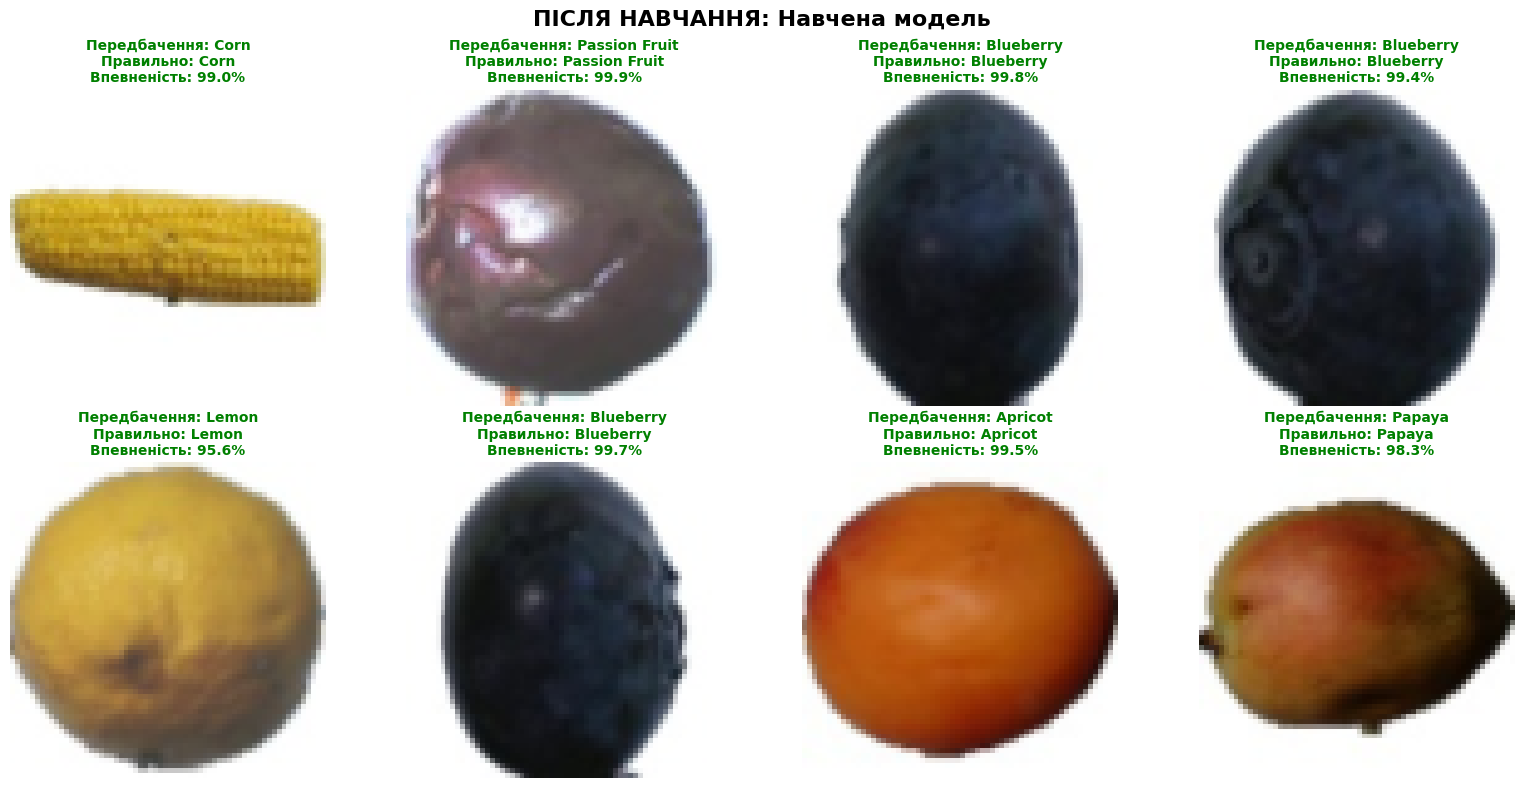

In [101]:
print('\n' + '='*60)
print('ПЕРЕДБАЧЕННЯ ПІСЛЯ НАВЧАННЯ')
print('='*60)

show_predictions(model, testloader, dataset, n_images=8, 
                title="ПІСЛЯ НАВЧАННЯ: Навчена модель")

In [102]:
# Точність ПІСЛЯ навчання
model.eval()
correct_after = 0
total_after = 0

with torch.no_grad():
    for imgs, labels in testloader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        predictions = model(imgs).argmax(1)
        correct_after += (predictions == labels).sum().item()
        total_after += len(labels)

accuracy_after = (correct_after / total_after) * 100
print(f'Точність ПІСЛЯ навчання: {accuracy_after:.2f}%')

Точність ПІСЛЯ навчання: 95.04%


In [103]:
print(len(losslist), len(losstestlist))
print(len(accuracytrainlist), len(accuracytestlist))
print(len(avg_train_acc_list), len(avg_test_acc_list))

530 140
530 140
10 10


ГРАФІКИ

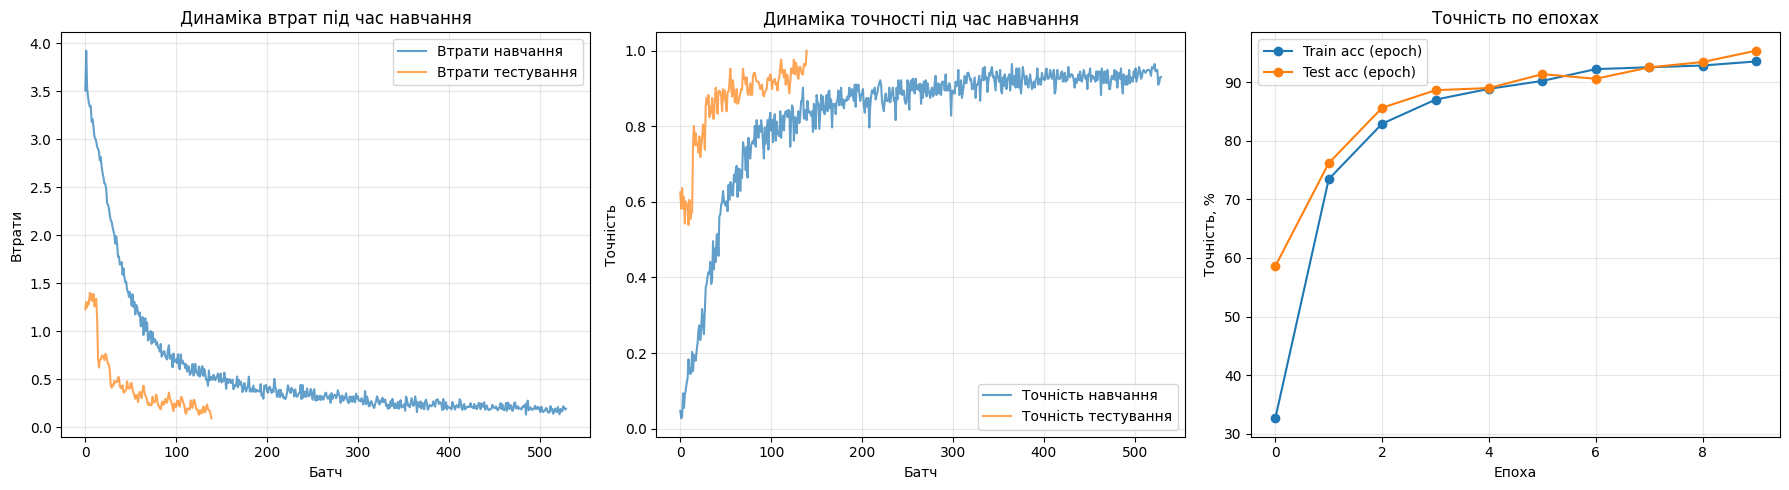

In [104]:
# ГРАФІКИ: втрати, точність по батчах, точність по епохах
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# 1) Динаміка втрат
ax1.plot(losslist, label='Втрати навчання', alpha=0.7)
ax1.plot(losstestlist, label='Втрати тестування', alpha=0.7)
ax1.set_xlabel('Батч')
ax1.set_ylabel('Втрати')
ax1.set_title('Динаміка втрат під час навчання')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2) Динаміка точності
ax2.plot(accuracytrainlist, label='Точність навчання', alpha=0.7)
ax2.plot(accuracytestlist, label='Точність тестування', alpha=0.7)
ax2.set_xlabel('Батч')
ax2.set_ylabel('Точність')
ax2.set_title('Динаміка точності під час навчання')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3) Точність по епохах
ax3.plot(avg_train_acc_list, label='Train acc (epoch)', marker='o')
ax3.plot(avg_test_acc_list, label='Test acc (epoch)', marker='o')
ax3.set_xlabel('Епоха')
ax3.set_ylabel('Точність, %')
ax3.set_title('Точність по епохах')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

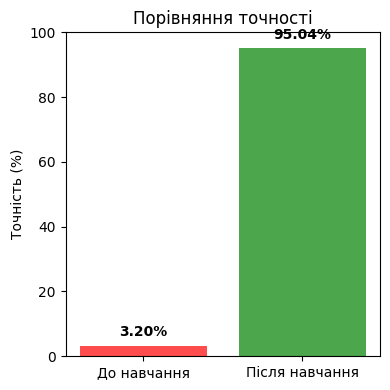

In [105]:
# ОКРЕМИЙ BAR-ГРАФІК "ДО / ПІСЛЯ"
plt.figure(figsize=(4, 4))

plt.bar(['До навчання', 'Після навчання'],
        [accuracy_before, accuracy_after],
        color=['red', 'green'], alpha=0.7)

plt.ylabel('Точність (%)')
plt.title('Порівняння точності')
plt.ylim(0, 100)

for i, v in enumerate([accuracy_before, accuracy_after]):
    plt.text(i, v + 2, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

ПІДСУМОК

In [106]:
print('\n' + '='*60)
print('ПІДСУМОК')
print('='*60)
print(f'Точність ДО навчання:    {accuracy_before:.2f}%')
print(f'Точність ПІСЛЯ навчання: {accuracy_after:.2f}%')
print(f'Покращення:              +{accuracy_after - accuracy_before:.2f}%')
print('='*60)

# Збереження моделі
torch.save(model.state_dict(), 'fruit_model.pth')
print('Модель збережена у файл: fruit_model.pth')


ПІДСУМОК
Точність ДО навчання:    3.20%
Точність ПІСЛЯ навчання: 95.04%
Покращення:              +91.84%
Модель збережена у файл: fruit_model.pth
